In [1]:
import numpy as np
import networkx as nx

import fugu
from fugu import Scaffold, Brick
from fugu.bricks import Vector_Input, PRN
from fugu.backends import snn_Backend

In [2]:
# Let's take a look at all valid input coding types.
fugu.input_coding_types

['current',
 'unary-B',
 'unary-L',
 'binary-B',
 'binary-L',
 'temporal-B',
 'temporal-L',
 'Raster',
 'Population',
 'Rate',
 'Undefined']

In [3]:
class RingTracker(Brick):
    def __init__(self, ring_size, name=None):
        super().__init__()
        self.ring_size = ring_size
        self.name = name
        self.is_built = False
        # It doesn't really matter what coding type it is.
        self.supported_codings = fugu.input_coding_types
        # We want the inputs to have two dimensions since we have one particle.
        self.dimensionality = {'D': 1}
    
    def build(self, graph, metadata, controlled_nodes, inputs, input_codings):
        if len(inputs) != 2:
            raise ValueError("you need the start position and the PRN")

        output_codings = [input_codings[0]]
        completed_node_name = self.name + "_complete"
        graph.add_node(completed_node_name, index = -1, threshold = 0.0, decay = 0.0, p = 1.0, potential = 0.0)
        graph.add_edge(controlled_nodes[0]['complete'], completed_node_name, weight = 1.0, delay = 1.0)

        clock_name = self.name + "_clock"
        graph.add_node(clock_name, threshold = 0.7, decay = 1.0, p = 1.0, potential = 0.0)
        graph.add_edge(clock_name, clock_name, weight = 1.0, delay = 1)
        graph.add_edge(controlled_nodes[0]['complete'], clock_name, weight = 1.0, delay = 1)

        ring_neurons = []
        for i in range(self.ring_size):
            neuron_name = self.name + f"_ring_{i}"
            graph.add_node(neuron_name, index = i, threshold = 0.9, decay = 1.0, p = 1.0, potential = 0.0)
            ring_neurons.append(neuron_name)

        right_neurons = []
        left_neurons = []
        for i in range(self.ring_size):
            right_name = self.name + f"_right_{i}"
            left_name = self.name + f"_left_{i}"

            graph.add_node(right_name, threshold = 1.9, decay = 1.0, p = 1.0, potential = 0.0)
            graph.add_node(left_name, threshold = 1.9, decay = 1.0, p = 1.0, potential = 0.0)

            right_neurons.append(right_name)
            left_neurons.append(left_name)

        prn_neuron = inputs[1][0]

        for i in range(self.ring_size):
            right_neighbor = (i + 1) % self.ring_size
            left_neighbor = (i - 1) % self.ring_size

            graph.add_edge(ring_neurons[i], right_neurons[i], weight = 1.0, delay = 1)
            graph.add_edge(ring_neurons[i], left_neurons[i], weight = 1.0, delay = 1)

            graph.add_edge(prn_neuron, right_neurons[i], weight = 1.0, delay = 1)
            graph.add_edge(prn_neuron, left_neurons[i], weight = -10.0, delay = 1)

            graph.add_edge(clock_name, left_neurons[i], weight = 1.0, delay = 1)

            graph.add_edge(right_neurons[i], ring_neurons[right_neighbor], weight = 2.0, delay = 1)
            graph.add_edge(left_neurons[i], ring_neurons[left_neighbor], weight = 2.0, delay = 1)

        start_neuron = inputs[0][0]
        graph.add_edge(start_neuron, ring_neurons[0], weight = 2.0, delay = 1)

        self.is_built = True
        output_lists = [ring_neurons]
        return (graph, self.dimensionality, [{'complete': completed_node_name}], output_lists, output_codings)


Scaffold is built: True
-------------------------------------------------------
Bricks:

Brick No.: 0
Brick Tag: start-0
Brick Name: start
{'tag': 'start-0', 'name': 'start', 'brick': <fugu.bricks.input_bricks.Vector_Input object at 0x110535690>, 'layer': 'input', 'ports': {'output': PortData(spec=PortSpec(name='output', description='', index=0, minimum=1, maximum=1, channels={'data': ChannelSpec(name='data', description='', coding='Undefined', shape=(1,), required=True), 'begin': ChannelSpec(name='begin', description='', coding=[], shape=(1,), required=True), 'complete': ChannelSpec(name='complete', description='', coding=[], shape=(1,), required=True)}), channels={'data': ChannelData(spec=ChannelSpec(name='data', description='', coding='Undefined', shape=(1,), required=True), neurons=['start-0:(0,)']), 'begin': ChannelData(spec=ChannelSpec(name='begin', description='', coding=[], shape=(1,), required=True), neurons=['start-0:begin']), 'complete': ChannelData(spec=ChannelSpec(name='co

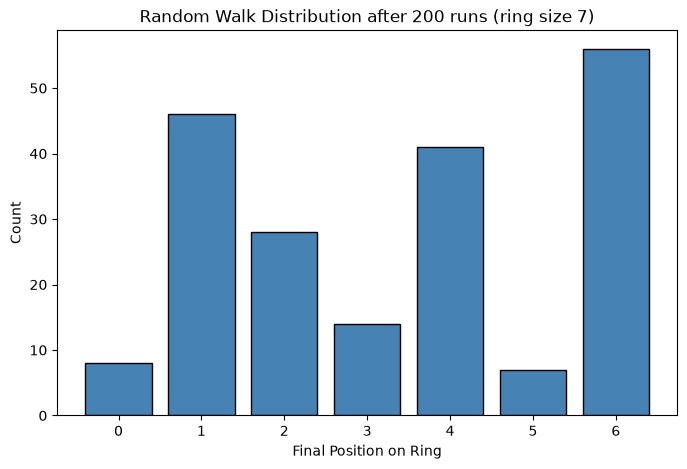

Completed 200 runs
Position counts: {0: 8, 1: 46, 2: 28, 3: 14, 4: 41, 5: 7, 6: 56}


In [4]:
scaffold = Scaffold()
scaffold.add_brick(
    Vector_Input(np.array([1]), coding='Undefined', name='start'),
    'input'
)
scaffold.add_brick(
    PRN(probability=0.5, steps=20, shape=(1,), name='coin'),
    [(0, 0)]
)
scaffold.add_brick(
    RingTracker(ring_size=7, name='ring'),
    [(0, 0), (1, 0)],
    output=True
)

scaffold.lay_bricks()
scaffold.summary(verbose=1)

backend = snn_Backend()
backend_args = {'record': 'all'}
backend.compile(scaffold, backend_args)

import matplotlib.pyplot as plt

# Map neuron numbers to ring positions
ring_neuron_map = {8: 0, 9: 1, 10: 2, 11: 3, 12: 4, 13: 5, 14: 6}
ring_neuron_numbers = set(ring_neuron_map.keys())

positions = []
num_runs = 200

for _ in range(num_runs):
    backend.compile(scaffold, backend_args)
    result = backend.run(20)
    
    # Get only ring neuron firings
    ring_firings = result[result['neuron_number'].isin(ring_neuron_numbers)]
    
    if len(ring_firings) > 0:
        # Get the last time any ring neuron fired
        last_time = ring_firings['time'].max()
        final_position = ring_firings[ring_firings['time'] == last_time]['neuron_number'].values[0]
        positions.append(ring_neuron_map[final_position])

plt.figure(figsize=(8, 5))
plt.hist(positions, bins=range(8), align='left', rwidth=0.8, color='steelblue', edgecolor='black')
plt.xlabel('Final Position on Ring')
plt.ylabel('Count')
plt.title(f'Random Walk Distribution after {num_runs} runs (ring size 7)')
plt.xticks(range(7))
plt.show()

print(f"Completed {len(positions)} runs")
print(f"Position counts: {dict(zip(*[range(7), [positions.count(i) for i in range(7)]]))}")

In [5]:
for node, data in scaffold.graph.nodes(data=True):
    if 'ring' in str(node):
        print(node, data)

ring_complete {'index': -1, 'threshold': 0.0, 'decay': 0.0, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-2', 'neuron_number': 6}
ring_clock {'threshold': 0.7, 'decay': 1.0, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-2', 'neuron_number': 7}
ring_ring_0 {'index': 0, 'threshold': 0.9, 'decay': 1.0, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-2', 'neuron_number': 8}
ring_ring_1 {'index': 1, 'threshold': 0.9, 'decay': 1.0, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-2', 'neuron_number': 9}
ring_ring_2 {'index': 2, 'threshold': 0.9, 'decay': 1.0, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-2', 'neuron_number': 10}
ring_ring_3 {'index': 3, 'threshold': 0.9, 'decay': 1.0, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-2', 'neuron_number': 11}
ring_ring_4 {'index': 4, 'threshold': 0.9, 'decay': 1.0, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-2', 'neuron_number': 12}
ring_ring_5 {'index': 5, 'threshold': 0.9, 'decay': 1.0, 'p': 1.0, 'potential': 0.0, 'brick': 'Brick-2', 'neuron_number': 13}
ring_r